In [9]:
import random

from viz import draw_state
import numpy as np
from env import SimpleARGEnvironment
from rollout_worker_arg import RolloutWorker
from tb_gfn import TBGFlowNetGenerator
from utils import load_sequences

In [18]:
Ne = 10000
r_per_bp = 1e-8
sequence_length = 8

rho = 4 * Ne * r_per_bp * sequence_length
dataset_path = "../dataset/DS1.pickle"
sequences = load_sequences(dataset_path)

In [19]:
len(sequences[0])

1949

In [ ]:
env = SimpleARGEnvironment(
        num_sequences=len(sequences),
        sequence_length=len(sequences[0]),
        rho=rho,
        sequences=sequences,
        num_blocks=10,
        fixed_edge_length=0.02,
        rng=random.Random(7),
    )

generator = TBGFlowNetGenerator(env)
rollout_worker = RolloutWorker(env)

In [23]:
state, traj = rollout_worker.rollout(generator)
# draw_state(state[0])

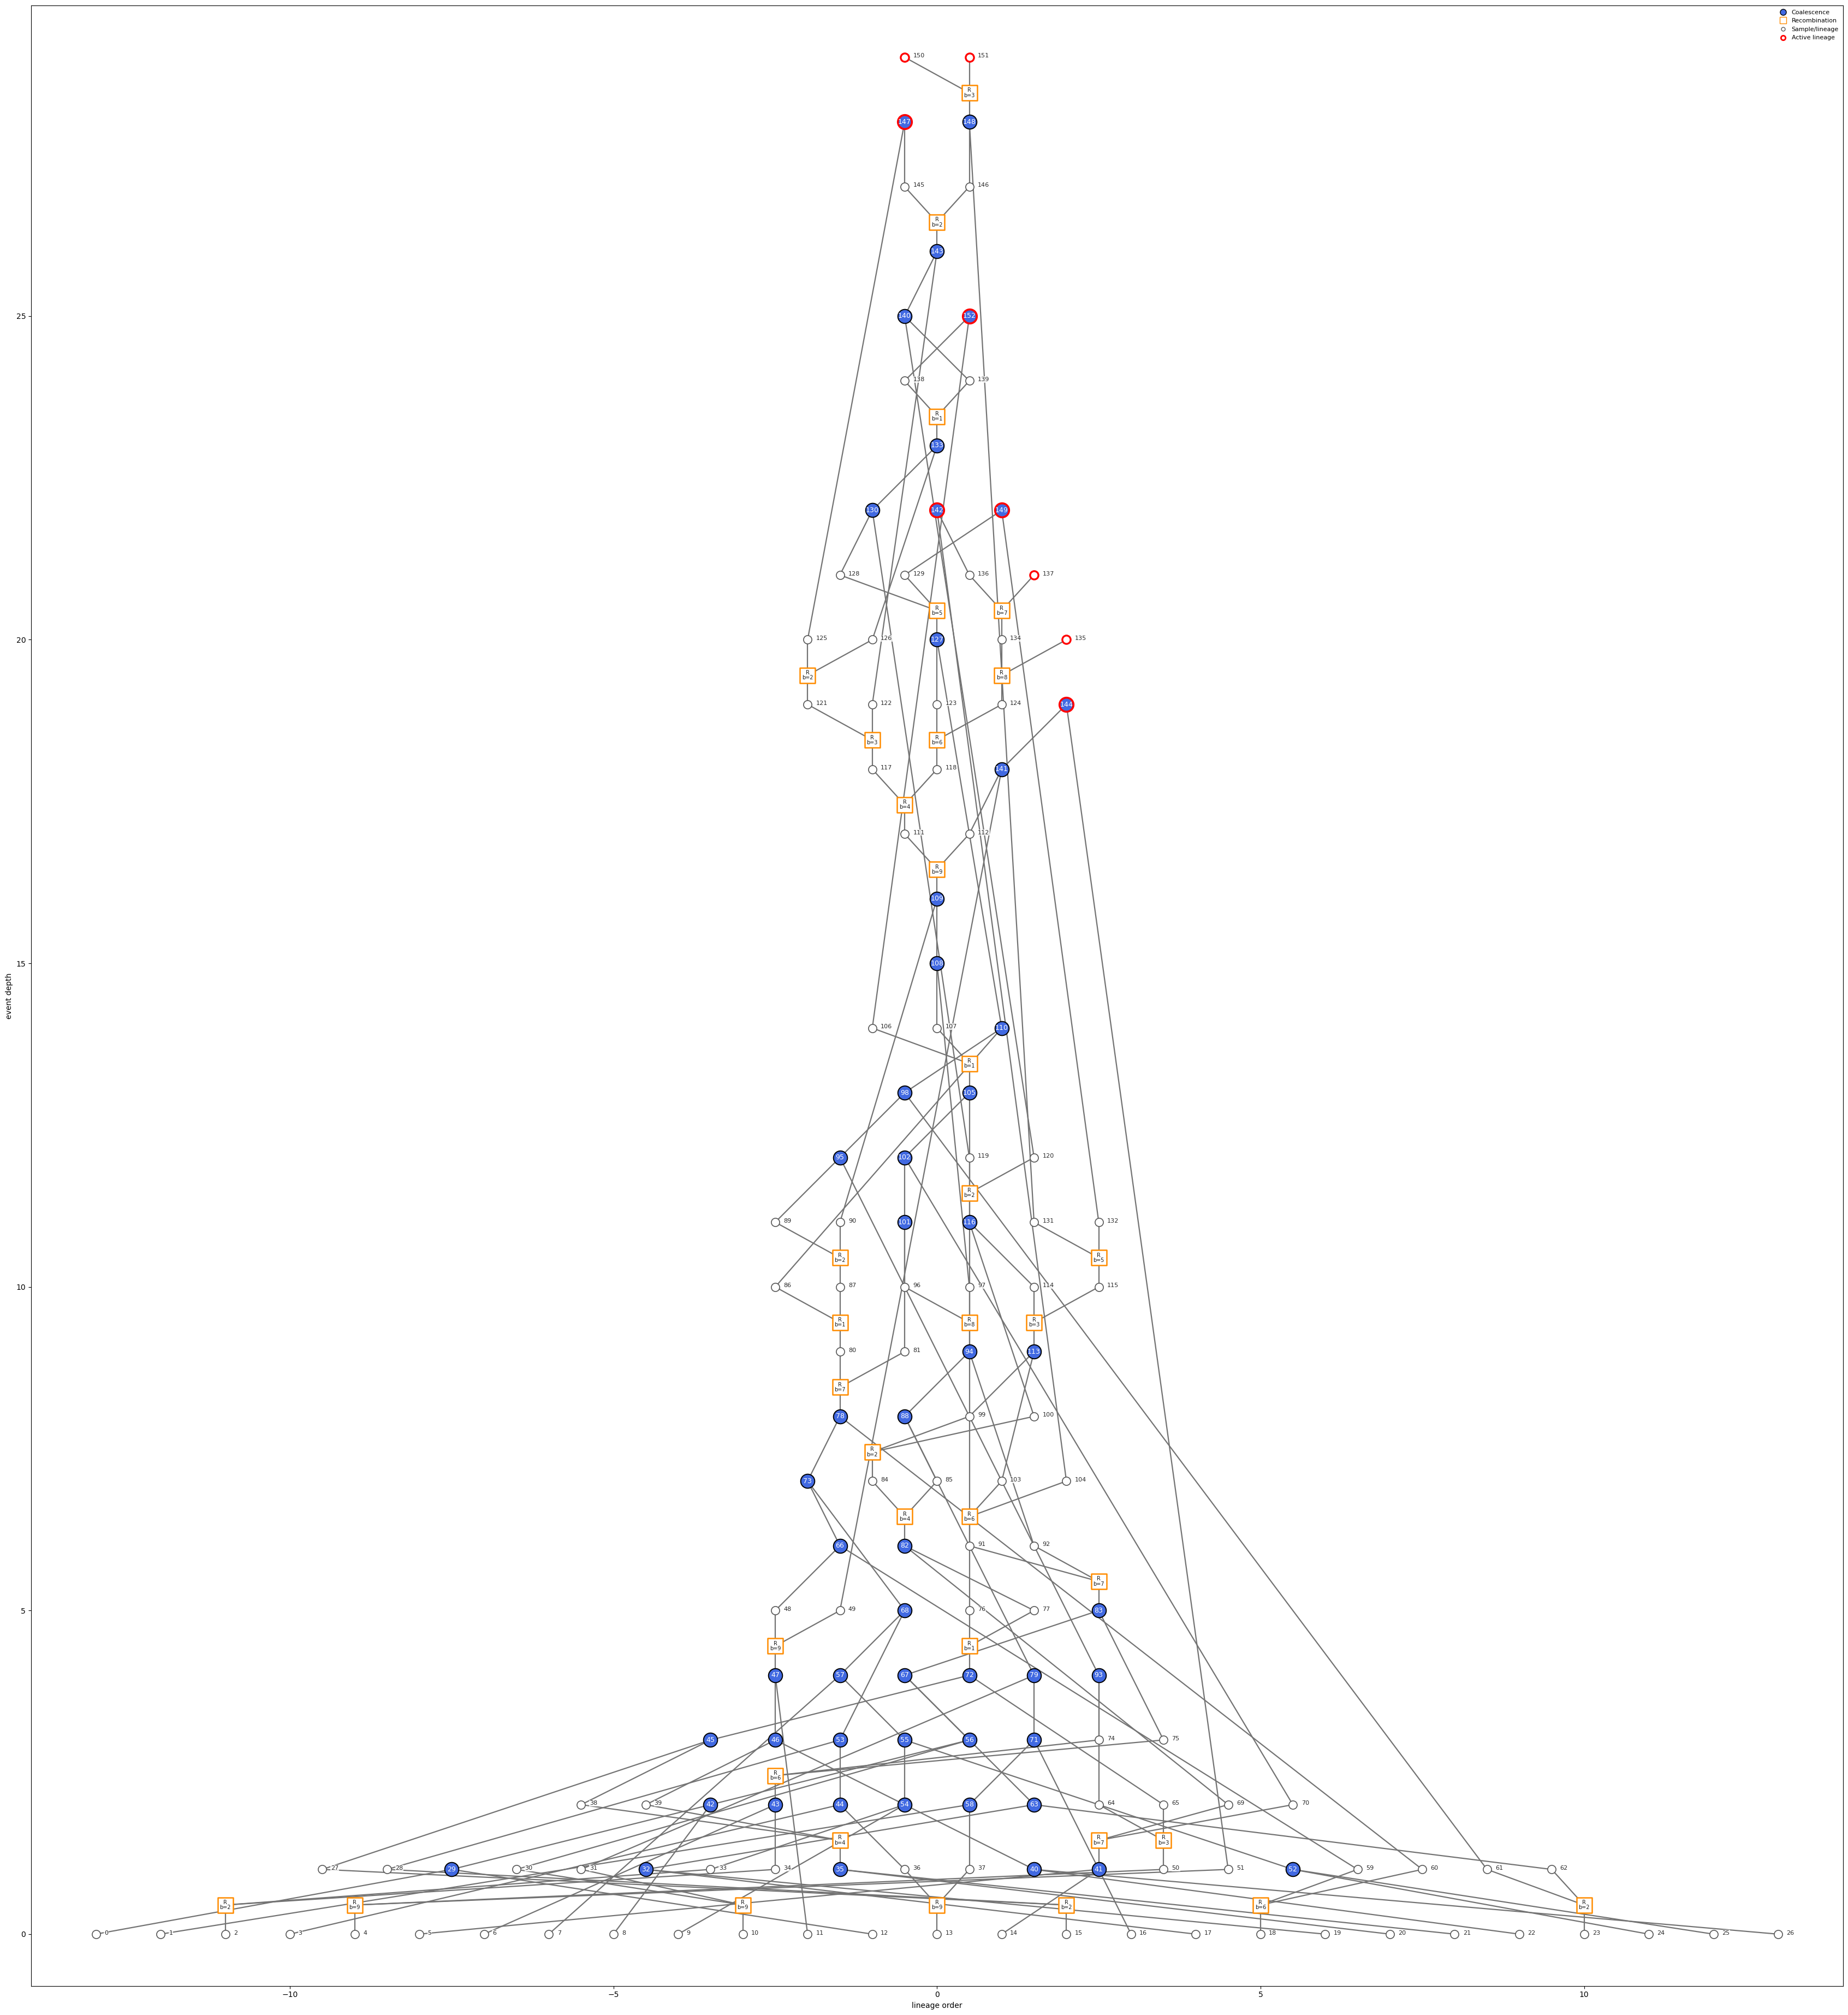

(<Figure size 3710x3700 with 1 Axes>,
 <Axes: xlabel='lineage order', ylabel='event depth'>)

In [25]:
draw_state(state[0])

In [24]:
env.save_to_tree_sequence(state[0], "example.trees")

In [ ]:
act_seg = env.get_arg_sequence_segments(state[0])
[(b['child_node_id'], b['parent_node_ids']) for b in act_seg['recombination_events']]